In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate the data

In [3]:
SEED = 1234
NUM_SAMPLES = 50

In [4]:
np.random.seed(SEED)

In [5]:
def generate_data(num_samples):
    """ Generate DUMMY data for linear regression. """
    weight = 3.5
    X = np.array(range(num_samples))
    random_noise = np.random.uniform(-10, 20, size=num_samples)
    y = weight * X + random_noise
    return X, y

In [6]:
# Generate random data
X, y = generate_data(num_samples=NUM_SAMPLES)
data = np.array([X, y]).T
print(f"Data Sample: \n{data[:5]}")

Data Sample: 
[[ 0.         -4.25441649]
 [ 1.         12.16326313]
 [ 2.         10.13183217]
 [ 3.         24.06075751]
 [ 4.         27.39927424]]


In [7]:
# Load into a Pandas DataFrame
df = pd.DataFrame(data, columns=["X", "y"])
df.head()

,X,y
0,0.0,-4.254416
1,1.0,12.163263
2,2.0,10.131832
3,3.0,24.060758
4,4.0,27.399274


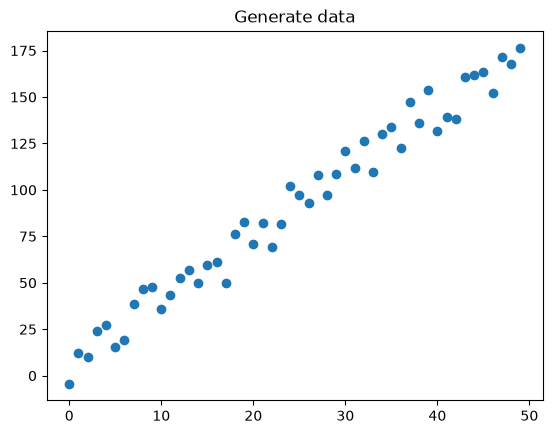

In [8]:
# Scatter plot
plt.title("Generate data")
plt.scatter(x=df["X"], y=df["y"])
plt.show();

# 2. Split data 

The data should be split into `train_set` and `test_set`.

In [9]:
TRAIN_SIZE = 0.7
VAL_SIZE = 0.15
TEST_SIZE = 0.15

In [10]:
# Shuffle data
indices = list(range(NUM_SAMPLES))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]
# print(indices)
print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (50,) | y shape: (50,)


In [11]:
# Split indices
train_start = 0
train_end = int(TRAIN_SIZE * NUM_SAMPLES)
val_start = train_end
val_end = int((TRAIN_SIZE + VAL_SIZE) * NUM_SAMPLES)
test_start = val_end

In [12]:
X_train = X[train_start:train_end]
y_train = y[train_start:train_end]
X_val = X[val_start:val_end]
y_val = y[val_start:val_end]
X_test = X[test_start:]
y_test = y[test_start:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (35,), y_train: (35,)
X_val: (7,), y_val: (7,)
X_test: (8,), y_test: (8,)


# 3. Standardize data

We need to standardize our data (zero mean and unit variance) so a specific feature magnitude doesn't effect how the model learns its weights

In [13]:
def standardize_data(data, mean, std):
    return (mean - data) / std

In [14]:
X_mean = np.mean(X_train)
X_std = np.std(X_train)
y_mean = np.mean(y_train)
y_std = np.std(y_train)

In [15]:
X_train = standardize_data(X_train, X_mean, X_std)
y_train = standardize_data(y_train, y_mean, y_std)
X_val = standardize_data(X_val, X_mean, X_std)
y_val = standardize_data(y_val, y_mean, y_std)
X_test = standardize_data(X_test, X_mean, X_std)
y_test = standardize_data(y_test, y_mean, y_std)

In [16]:
X_test.shape

(8,)

In [17]:
print (f"mean: {np.mean(X_test):.1f}, std: {np.std(X_test):.1f}")
print (f"mean: {np.mean(y_test):.1f}, std: {np.std(y_test):.1f}")

mean: 0.6, std: 0.9
mean: 0.6, std: 0.9


# 4. Weight

In [23]:
# Step 1: Randomly intialize the model's weight

INPUT_DIM = 1
OUTPUT_DIM = 1

In [24]:
# intialize random weight

W = 0.01 * np.random.randn(INPUT_DIM, OUTPUT_DIM)
b = np.zeros((1, 1))
print(f"W: {W.shape}")
print(f"b: {b.shape}")

W: (1, 1)
b: (1, 1)
